<a href="https://colab.research.google.com/github/Tasan99/Assignments/blob/main/Agents3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Working with a local LLM


In this notebook, we explore the power and advantages of running Large Language Models (LLMs) locally. While cloud-based proprietary LLMs offer convenience, they often come with significant costs, strict rate limits, and potential privacy concerns due to data being processed on external servers. By leveraging local LLMs, we gain full control over our data, ensure privacy, and eliminate ongoing API costs and rate limitations, making them an excellent choice for research, development, and applications requiring sensitive data handling. Here, we'll be working with a local Code Agent.

#The Local "Code Agent" (Qwen 2.5-Coder-3B-Instruct)
⚠️ **Important Colab Note: Ensure your runtime is set to T4 GPU (Runtime > Change runtime type > T4 GPU). This model fits tightly in the 16GB VRAM, so do not run other large models in the same session.**

Before we can run our local Code Agent, we need to install the necessary Python libraries. `smolagents` is our framework for building agents, while `transformers`, `accelerate`, and `bitsandbytes` are crucial for efficiently loading and running large language models on a GPU. `yfinance`, `seaborn`, and `matplotlib` are data science libraries the agent will use for financial data analysis and visualization.

In [1]:
# ==========================================
# Install Dependencies
# ==========================================
# We need 'accelerate' and 'bitsandbytes' to load the model efficiently on the GPU.
# Added 'duckduckgo_search' to enable web search capabilities for the agent.
!pip install -q smolagents transformers accelerate bitsandbytes yfinance seaborn matplotlib duckduckgo_search


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 101.3 MB/s eta 0:00:00


Now we'll load the `Qwen 2.5 Coder 3B` model. This model is specifically designed for code generation tasks. We're using `TransformersModel` from `smolagents` to load it. `device_map='auto'` ensures the model automatically utilizes the available T4 GPU, and `torch_dtype=torch.float16` reduces memory footprint by using half-precision floating-point numbers. `max_new_tokens` is set to allow for longer code outputs.

In [2]:
# ==========================================
# Load the 3B Model (Lightweight & Fast)
# ==========================================
from smolagents import CodeAgent, TransformersModel
import torch

print("⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...")

# We use the 3B-Instruct model.
# device_map="auto" finds the Colab GPU.
# torch_dtype=torch.float16 cuts memory usage in half.
model = TransformersModel(
    model_id="Qwen/Qwen2.5-Coder-3B-Instruct",
    device_map="auto",
    torch_dtype=torch.float16,
    max_new_tokens=2048  # Give it space to write longer scripts
)

print("✅ 3B Model loaded on GPU! Ready for coding.")

⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ 3B Model loaded on GPU! Ready for coding.


With the model loaded, we can now initialize our `CodeAgent`. We provide it with the loaded `model` and specify `additional_authorized_imports`. This list tells the agent which Python libraries it is allowed to use when generating and executing code. Crucially, we don't give it predefined tools; instead, it writes its own code using these authorized libraries, making it highly flexible.

In [3]:
# ==========================================
# Initialize the Agent
# ==========================================

# We authorize the agent to use specific data science libraries, and now also a web search library.
agent = CodeAgent(
    tools=[], # We don't need pre-made tools; the agent writes its own code.
    model=model,
    max_steps=3,
    additional_authorized_imports=[
        "yfinance",
        "pandas",
        "numpy",
        "seaborn",
        "matplotlib.pyplot",
        "duckduckgo_search" # Added for web search capabilities
    ]
)


#Coding task
*Download data for BTC-USD, ETH-USD, and SOL-USD for the last 90 days. Calculate the correlation matrix and plot it as a heatmap.*

Here, we're giving the `CodeAgent` a multi-step task to perform. It involves downloading financial data for cryptocurrencies using `yfinance`, calculating correlations, and then visualizing the results as a heatmap using `seaborn`. The agent will interpret this prompt, write the Python code, and then execute it to produce the `crypto_heatmap.png` file.

🤖 Agent is coding... (Watch the 'Thought' process below)


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 1. Download daily closing data for 'BTC-USD', 'ETH-USD', and 'SOL-USD' for the last 30 days using yfinance.     │
│ 2. Create a single DataFrame with these close prices.                                                           │
│ 3. Calculate the correlation matrix of the returns.                                                             │
│ 4. Plot this correlation matrix as a heatmap using seaborn with annotations.                                    │
│ 5. Save the plot as 'crypto_heatmap.png'.                                                                       │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import seaborn as sns                                                                                            
  import matplotlib.pyplot as plt                                                                                  
                                                                                                                   
  # Step 1: Download daily closing data for 'BTC-USD', 'ETH-USD', and 'SOL-USD' for the last 30 days               
  tickers = ['BTC-USD', 'ETH-USD', 'SOL-USD']                                                                      
  data = yf.download(tickers, period='30d')['Close']                                                               
                                                                                                                   
  # Step 2: Create a single DataFrame with these close prices                                                      
  df = pd.DataFrame(data)                                                                                          
                                                                                                                   
  # Step 3: Calculate the correlation matrix of the returns                                                        
  returns = df.pct_change().dropna()                                                                               
  correlation_matrix = returns.corr()                                                                              
                                                                                                                   
  # Step 4: Plot this correlation matrix as a heatmap using seaborn with annotations                               
  plt.figure(figsize=(10, 8))                                                                                      
  sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")                                          
  plt.title('Correlation Matrix of Crypto Returns')                                                                
                                                                                                                   
  # Step 5: Save the plot as 'crypto_heatmap.png'                                                                  
  plt.savefig('crypto_heatmap.png')                                                                                
                                                                                                                   
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import seaborn as sns                                                                                            
  import matplotlib.pyplot as plt                                                                                  
                                                                                                                   
  # Step 1: Download daily closing data for 'BTC-USD', 'ETH-USD', and 'SOL-USD' for the last 30 days               
  tickers = ['BTC-USD', 'ETH-USD', 'SOL-USD']                                                                      
  data = yf.download(tickers, period='30d')['Close']                                                               
                                                                                                                   
  # Step 2: Create a single DataFrame with these close pr

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  !pip install yfinance pandas seaborn matplotlib                                                                  
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import seaborn as sns                                                                                            
  import matplotlib.pyplot as plt                                                                                  
                                                                                                                   
  # Step 1: Download daily closing data for 'BTC-USD', 'ETH-USD', and 'SOL-USD' for the last 30 days               
  tickers = ['BTC-USD', 'ETH-USD', 'SOL-USD']                                                                      
  data = yf.download(tickers, period='30d')['Close']                                                               
                                                                                                                   
  # Step 2: Create a single DataFrame with these close prices                                                      
  df = pd.DataFrame(data)                                                                                          
                                                                                                                   
  # Step 3: Calculate the correlation matrix of the returns                                                        
  returns = df.pct_change().dropna()                                                                               
  correlation_matrix = returns.corr()                                                                              
                                                                                                                   
  # Step 4: Plot this correlation matrix as a heatmap using seaborn with annotations                               
  plt.figure(figsize=(10, 8))                                                                                      
  sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")                                          
  plt.title('Correlation Matrix of Crypto Returns')                                                                
                                                                                                                   
  # Step 5: Save the plot as 'crypto_heatmap.png'                                                                  
  plt.savefig('crypto_heatmap.png')                                                                                
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Code parsing failed on line 1 due to: SyntaxError: invalid syntax (<unknown>, line 1)
!pip install yfinance pandas seaborn matplotlib
 ^

[Step 3: Duration 28.65 seconds| Input tokens: 9,176 | Output tokens: 1,685]

Reached max steps.

[Step 4: Duration 44.59 seconds| Input tokens: 11,745 | Output tokens: 2,333]

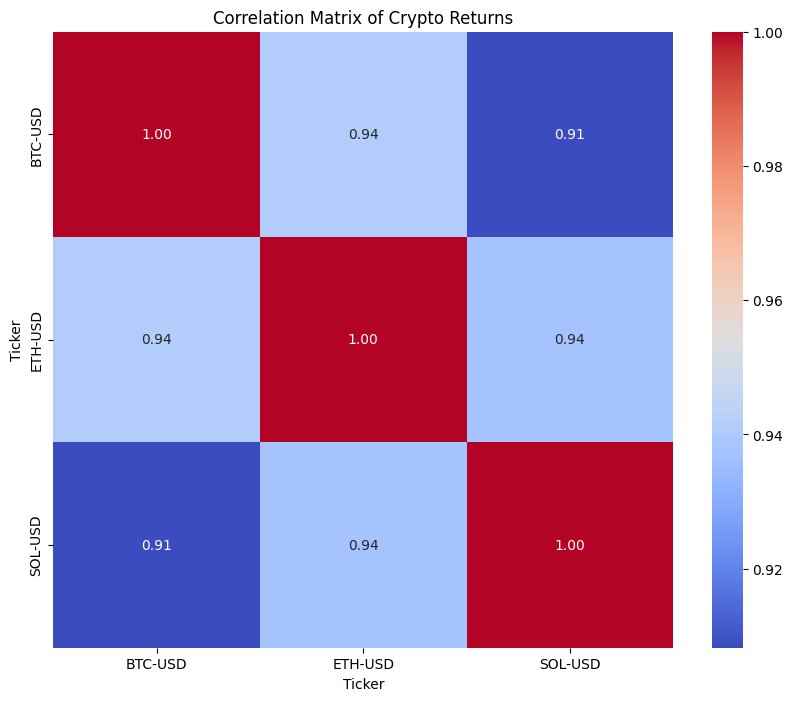

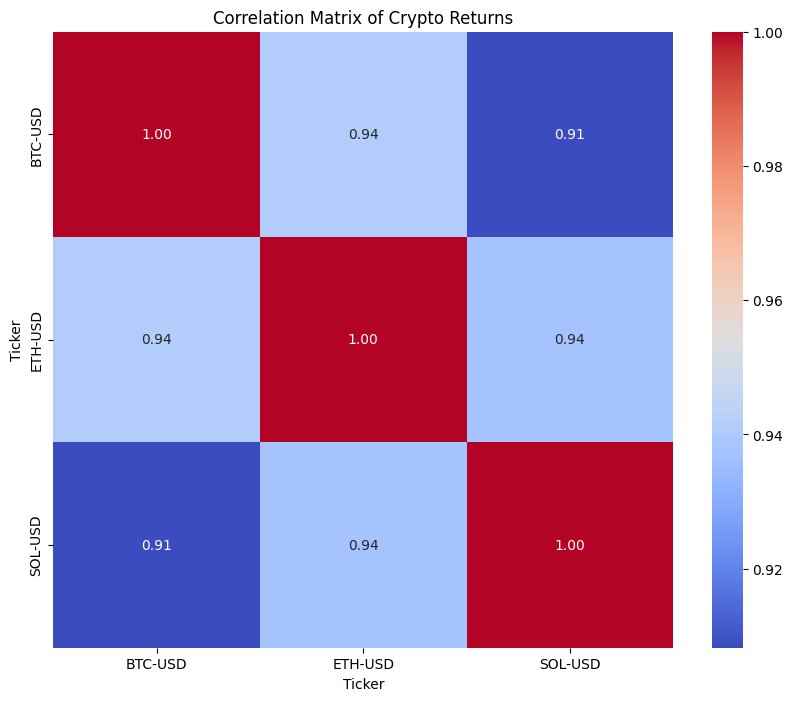

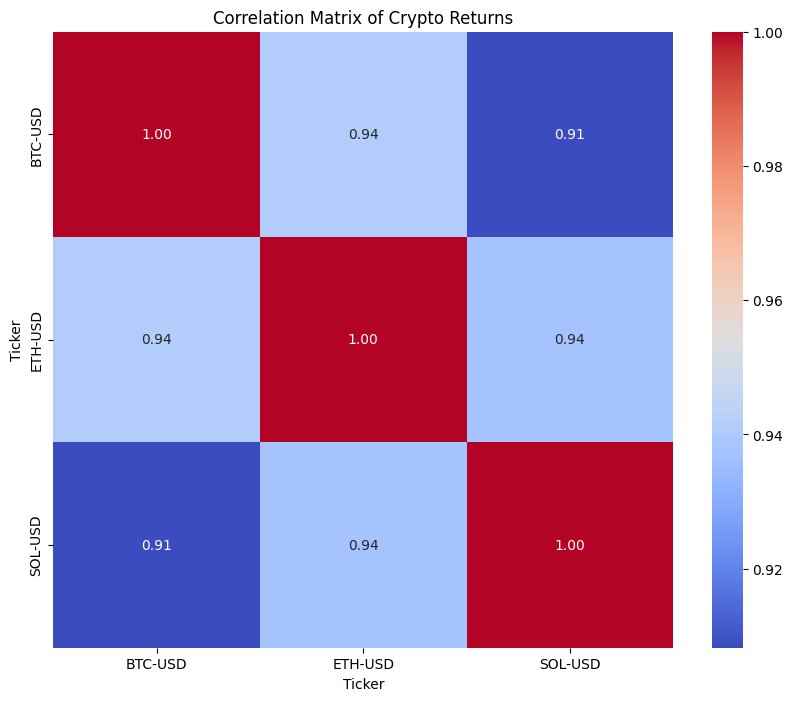

In [4]:
# ==========================================
# Execute the Crypto Heatmap Task
# ==========================================
# We give it a complex multi-step instruction.
task_prompt = """
1. Download daily closing data for 'BTC-USD', 'ETH-USD', and 'SOL-USD' for the last 30 days using yfinance.
2. Create a single DataFrame with these close prices.
3. Calculate the correlation matrix of the returns.
4. Plot this correlation matrix as a heatmap using seaborn with annotations.
5. Save the plot as 'crypto_heatmap.png'.
"""

print("🤖 Agent is coding... (Watch the 'Thought' process below)")
result = agent.run(task_prompt,stream=False)

In [5]:
print(result)

Thought: Since the previous approach resulted in a syntax error, let's try a different method to install the required packages and execute the code. We can use the `subprocess` module to run the installation command in a shell.

Code:
```python
import subprocess
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Install the required packages
subprocess.run(['pip', 'install', 'yfinance', 'pandas', 'seaborn', 'matplotlib'])

# Step 2: Download daily closing data for 'BTC-USD', 'ETH-USD', and 'SOL-USD' for the last 30 days
tickers = ['BTC-USD', 'ETH-USD', 'SOL-USD']
data = yf.download(tickers, period='30d')['Close']

# Step 3: Create a single DataFrame with these close prices
df = pd.DataFrame(data)

# Step 4: Calculate the correlation matrix of the returns
returns = df.pct_change().dropna()
correlation_matrix = returns.corr()

# Step 5: Plot this correlation matrix as a heatmap using seaborn with annotations
plt.figure(figsize=(10, 

After the agent has attempted to generate and save the heatmap, this code block checks if the `crypto_heatmap.png` file exists. If it does, it uses `IPython.display` to show the generated image directly within the Colab output. This allows us to visually inspect the agent's output.


📊 Displaying Generated Heatmap:


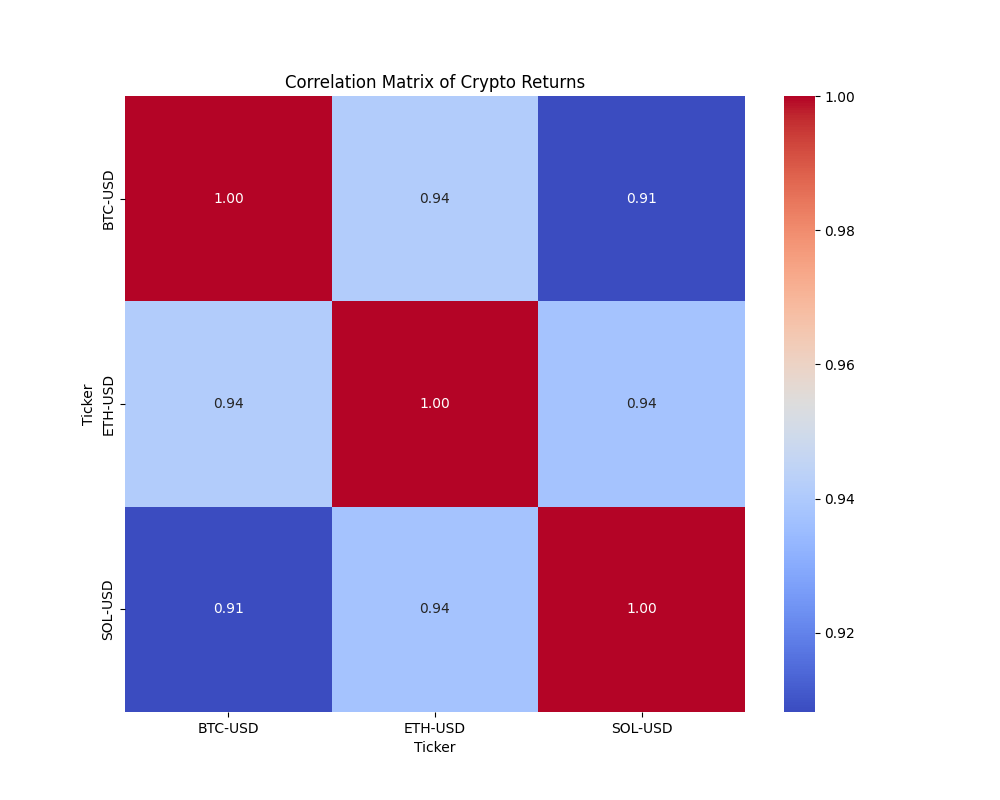

In [6]:
# ==========================================
# Display the Result
# ==========================================
import IPython
import os

if os.path.exists("crypto_heatmap.png"):
    print("\n📊 Displaying Generated Heatmap:")
    IPython.display.display(IPython.display.Image("crypto_heatmap.png"))
else:
    print("⚠️ No image file found. Check the agent's output logs above for errors.")

#Let's replicate previous tasks with the local LLM


This task demonstrates the agent's ability to perform data analysis using `pandas`. We ask it to fetch historical stock data for NVIDIA (`NVDA`), calculate the daily percentage returns, and then determine the standard deviation (volatility) of these returns. The agent will write the necessary `yfinance` and `pandas` code to achieve this.

In [7]:
# The "Pandas" Task
# We ask for a calculation that requires fetching data and doing math.

task = """
Get the historical closing prices for 'NVDA' for the last 1 month.
Calculate the standard deviation of the daily percentage returns (volatility).
Print the volatility as a percentage.
"""

result=agent.run(task,stream=False)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Get the historical closing prices for 'NVDA' for the last 1 month.                                              │
│ Calculate the standard deviation of the daily percentage returns (volatility).                                  │
│ Print the volatility as a percentage.                                                                           │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import numpy as np                                                                                               
                                                                                                                   
  # Fetch historical data for NVDA                                                                                 
  nvda = yf.download('NVDA', start='2023-09-01', end='2023-10-01')                                                 
                                                                                                                   
  # Calculate daily percentage returns                                                                             
  daily_returns = nvda['Close'].pct_change()                                                                       
                                                                                                                   
  # Calculate the standard deviation of daily percentage returns                                                   
  volatility = np.std(daily_returns)                                                                               
                                                                                                                   
  # Print the volatility as a percentage                                                                           
  print(f"Volatility of NVDA over the last month: {volatility * 100:.2f}%")                                        
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


Code execution failed at line 'print(f"Volatility of NVDA over the last month: {volatility * 100:.2f}%")' due to: 
TypeError: unsupported format string passed to Series.__format__

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Error in code parsing:
Your code snippet is invalid, because the regex pattern <code>(.*?)</code> was not found in it.
            Here is your code snippet:
            Thought: The code executed successfully, and the volatility of NVDA over the last month was calculated 
and printed as a percentage.

Final Answer: 1.67%</code>
            Make sure to include code with the correct pattern, for instance:
            Thoughts: Your thoughts
            <code>
            # Your python code here
            </code>
Make sure to provide correct code blobs.

[Step 3: Duration 5.15 seconds| Input tokens: 7,783 | Output tokens: 743]

Reached max steps.

[Step 4: Duration 28.72 seconds| Input tokens: 9,109 | Output tokens: 1,222]

In [8]:
print(result)

Thought: To solve this task, I need to use the following tools:
1. `yfinance` to fetch historical stock prices.
2. `pandas` to manipulate the data.
3. `numpy` to calculate the standard deviation.
4. `matplotlib.pyplot` to visualize the data if needed.

I will first import the necessary libraries and then use the `yfinance` tool to fetch the historical data for 'NVDA'. After that, I will calculate the daily percentage returns and compute the standard deviation. Finally, I will print the volatility as a percentage.

```python
import yfinance as yf
import pandas as pd
import numpy as np

# Fetch historical data for NVDA
nvda = yf.download('NVDA', start='2023-09-01', end='2023-10-01')

# Calculate daily percentage returns
daily_returns = nvda['Close'].pct_change()

# Calculate the standard deviation of daily percentage returns
volatility = np.std(daily_returns)

# Convert volatility to a float and format it as a percentage
volatility_percentage = float(volatility) * 100

# Print the volati

In this visual task, the agent is instructed to fetch Bitcoin (BTC-USD) closing prices, calculate a 7-day moving average, and then plot both on a chart using `matplotlib`. The goal is to see if the agent can generate a complete visualization and save it as an image file (`btc_chart.png`). A helper snippet is included to display the image if the agent doesn't do so automatically.

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Plot the closing price of Bitcoin (BTC-USD) for the last 3 months.                                              │
│ Add a 7-day moving average line to the chart.                                                                   │
│ Save the chart as 'btc_chart.png' and display it.                                                               │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import matplotlib.pyplot as plt                                                                                  
                                                                                                                   
  # Fetch the data for Bitcoin (BTC-USD) for the last 3 months                                                     
  btc_data = yf.download('BTC-USD', period='3mo')                                                                  
                                                                                                                   
  # Plotting the closing price                                                                                     
  plt.figure(figsize=(14, 7))                                                                                      
  plt.plot(btc_data['Close'], label='Closing Price', color='blue')                                                 
                                                                                                                   
  # Adding a 7-day moving average line                                                                             
  moving_average = btc_data['Close'].rolling(window=7).mean()                                                      
  plt.plot(moving_average, label='7-Day Moving Average', color='red')                                              
                                                                                                                   
  # Adding labels and title                                                                                        
  plt.xlabel('Date')                                                                                               
  plt.ylabel('Price (USD)')                                                                                        
  plt.title('Bitcoin Closing Price and 7-Day Moving Average')                                                      
  plt.legend()                                                                                                     
                                                                                                                   
  # Save the chart as 'btc_chart.png'                                                                              
  plt.savefig('btc_chart.png')                                                                                     
                                                                                                                   
  # Display the chart                                                                                              
  plt.show()                                                                                                       
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  1 of 1 completed


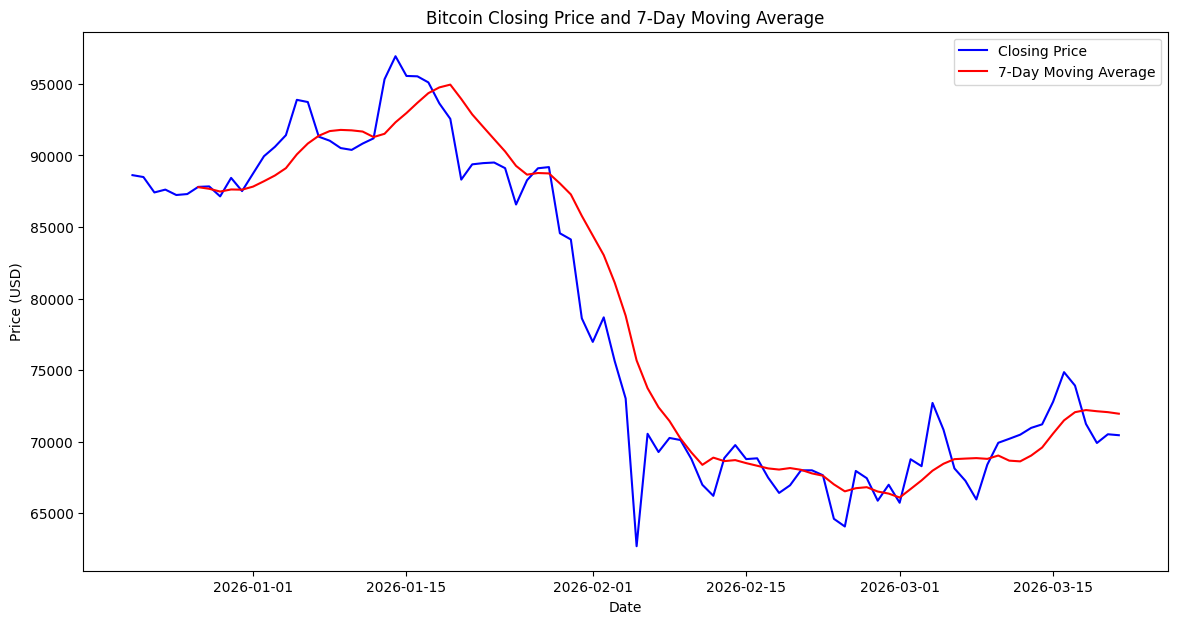

Out: None

[Step 1: Duration 19.49 seconds| Input tokens: 2,093 | Output tokens: 302]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Error in code parsing:
Your code snippet is invalid, because the regex pattern <code>(.*?)</code> was not found in it.
            Here is your code snippet:
            It looks like the code executed successfully, but there was no direct output displayed in the console. 
However, the chart was saved as 'btc_chart.png' in the working directory. If you want to see the chart, you can 
open the file manually.

If you need further assistance or have any other questions, feel free to ask!</code>
            Make sure to include code with the correct pattern, for instance:
            Thoughts: Your thoughts
            <code>
            # Your python code here
            </code>
Make sure to provide correct code blobs.

[Step 2: Duration 6.71 seconds| Input tokens: 4,713 | Output tokens: 370]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import matplotlib.pyplot as plt                                                                                  
                                                                                                                   
  # Fetch the data for Bitcoin (BTC-USD) for the last 3 months                                                     
  btc_data = yf.download('BTC-USD', period='3mo')                                                                  
                                                                                                                   
  # Plotting the closing price                                                                                     
  plt.figure(figsize=(14, 7))                                                                                      
  plt.plot(btc_data['Close'], label='Closing Price', color='blue')                                                 
                                                                                                                   
  # Adding a 7-day moving average line                                                                             
  moving_average = btc_data['Close'].rolling(window=7).mean()                                                      
  plt.plot(moving_average, label='7-Day Moving Average', color='red')                                              
                                                                                                                   
  # Adding labels and title                                                                                        
  plt.xlabel('Date')                                                                                               
  plt.ylabel('Price (USD)')                                                                                        
  plt.title('Bitcoin Closing Price and 7-Day Moving Average')                                                      
  plt.legend()                                                                                                     
                                                                                                                   
  # Save the chart as 'btc_chart.png'                                                                              
  plt.savefig('btc_chart.png')                                                                                     
                                                                                                                   
  # Display the chart                                                                                              
  plt.show()                                                                                                       
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  1 of 1 completed


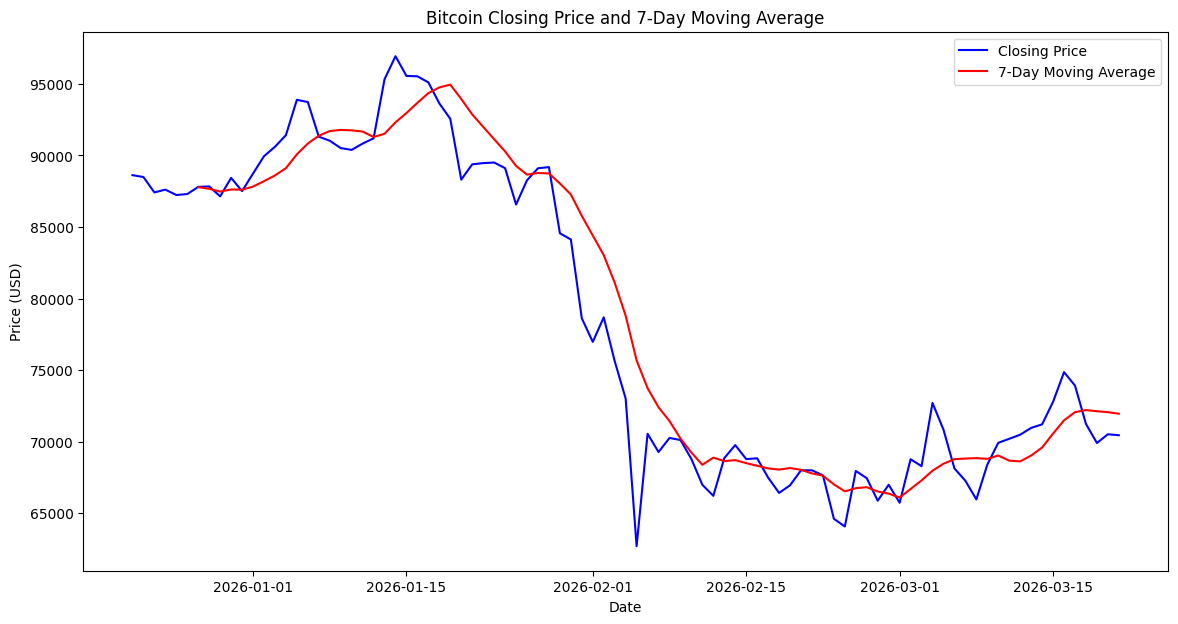

Out: None

[Step 3: Duration 36.90 seconds| Input tokens: 7,589 | Output tokens: 875]

Reached max steps.

[Step 4: Duration 4.19 seconds| Input tokens: 9,051 | Output tokens: 935]

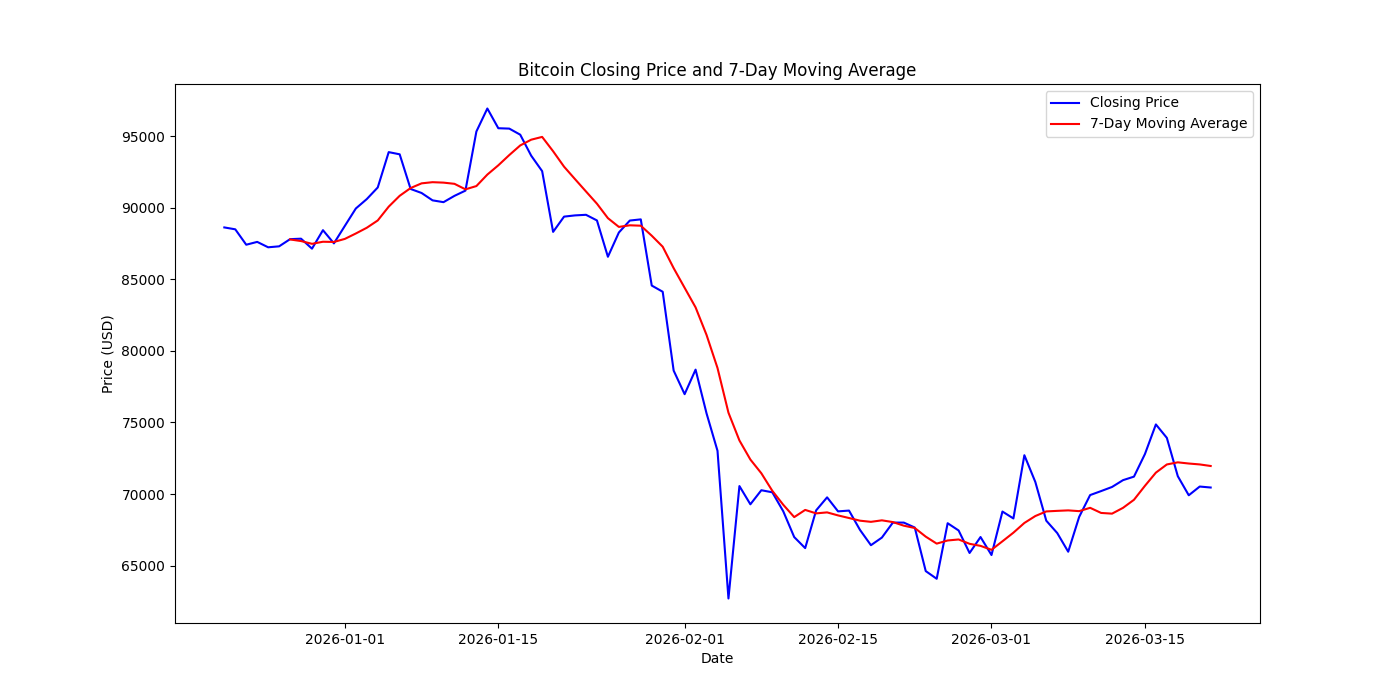

In [9]:
# The "Visual" Task
# The agent will use matplotlib to create a chart.

task_viz = """
Plot the closing price of Bitcoin (BTC-USD) for the last 3 months.
Add a 7-day moving average line to the chart.
Save the chart as 'btc_chart.png' and display it.
"""

agent.run(task_viz)

# Helper to show the image in Colab if the agent doesn't auto-display
import IPython
if os.path.exists("btc_chart.png"):
    IPython.display.display(IPython.display.Image("btc_chart.png"))

This task challenges the agent to act as a technical analyst. It needs to calculate the Relative Strength Index (RSI), a common momentum indicator, for Apple stock (`AAPL`) over a 14-day period. Based on the calculated RSI value, it should then determine if the stock is 'Overbought' or 'Oversold' according to standard thresholds.

In [10]:
# The Technical Analyst Task
task = """
Prompt: Calculate the Relative Strength Index (RSI) for Apple stock over the
last 14 days and tell me if it is currently 'Overbought' (>70) or 'Oversold' (<30).
"""

result = agent.run(task,stream=False)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Prompt: Calculate the Relative Strength Index (RSI) for Apple stock over the                                    │
│ last 14 days and tell me if it is currently 'Overbought' (>70) or 'Oversold' (<30).                             │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Step 1: Search for historical Apple stock prices                                                               
  prices = web_search(query="Apple stock prices last 14 days")                                                     
                                                                                                                   
  # Step 2: Parse the prices and calculate the RSI                                                                 
  rsi = calculate_rsi(prices)                                                                                      
                                                                                                                   
  # Step 3: Determine if the RSI is Overbought or Oversold                                                         
  if rsi > 70:                                                                                                     
      result = "Overbought"                                                                                        
  elif rsi < 30:                                                                                                   
      result = "Oversold"                                                                                          
  else:                                                                                                            
      result = "Neutral"                                                                                           
                                                                                                                   
  # Step 4: Output the result                                                                                      
  final_answer(result)                                                                                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Code execution failed at line 'prices = web_search(query="Apple stock prices last 14 days")' due to: 
InterpreterError: Forbidden function evaluation: 'web_search' is not among the explicitly allowed tools or 
defined/imported in the preceding code

[Step 1: Duration 13.97 seconds| Input tokens: 2,098 | Output tokens: 212]

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Step 1: Install yfinance library if not already installed                                                      
  install_library(library="yfinance")                                                                              
                                                                                                                   
  # Step 2: Fetch historical Apple stock prices                                                                    
  import yfinance as yf                                                                                            
                                                                                                                   
  prices = yf.download("AAPL", period="14d")["Close"]                                                              
                                                                                                                   
  # Step 3: Calculate the RSI                                                                                      
  rsi = calculate_rsi(prices)                                                                                      
                                                                                                                   
  # Step 4: Determine if the RSI is Overbought or Oversold                                                         
  if rsi > 70:                                                                                                     
      result = "Overbought"                                                                                        
  elif rsi < 30:                                                                                                   
      result = "Oversold"                                                                                          
  else:                                                                                                            
      result = "Neutral"                                                                                           
                                                                                                                   
  # Step 5: Output the result                                                                                      
  final_answer(result)                                                                                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Code execution failed at line 'install_library(library="yfinance")' due to: InterpreterError: Forbidden function 
evaluation: 'install_library' is not among the explicitly allowed tools or defined/imported in the preceding code

[Step 3: Duration 32.57 seconds| Input tokens: 7,714 | Output tokens: 1,016]

Reached max steps.

[Step 4: Duration 19.01 seconds| Input tokens: 9,342 | Output tokens: 1,325]

In [11]:
print(result)

Thought: To calculate the Relative Strength Index (RSI) for Apple stock over the last 14 days, I will use the historical stock prices. I will use the `yfinance` library to fetch the prices and then use the `calculate_rsi` function to compute the RSI. Finally, I will determine if the RSI is Overbought or Oversold based on the threshold values.
```python
# Step 1: Install yfinance library if not already installed
# Note: This step is typically done in the environment where the script is run, not in the code block.
# You can install it using pip: pip install yfinance

# Step 2: Fetch historical Apple stock prices
import yfinance as yf

prices = yf.download("AAPL", period="14d")["Close"]

# Step 3: Calculate the RSI
rsi = calculate_rsi(prices)

# Step 4: Determine if the RSI is Overbought or Oversold
if rsi > 70:
    result = "Overbought"
elif rsi < 30:
    result = "Oversold"
else:
    result = "Neutral"

# Step 5: Output the result
print(result)
```

Please note that the installation of 

This final task tests the agent's ability to combine information retrieval and data analysis. It's asked to first find the date of the next Federal Reserve meeting (which would typically involve a search tool, but here it's expected to generate code that could query an API or web scrape if it were set up for that, though in this context it's more about writing the *logic*). Then, it needs to calculate the volatility of the S&P 500 (`SPY`) around previous Fed meeting dates.

In [12]:
# Macro Researcher Task
task = """
Prompt: Search for the date of the next Federal Reserve meeting.
Then, calculate the average volatility of the S&P 500 (SPY) during the week of the previous 3 Fed meetings.
"""

result = agent.run(task,stream=False)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Prompt: Search for the date of the next Federal Reserve meeting.                                                │
│ Then, calculate the average volatility of the S&P 500 (SPY) during the week of the previous 3 Fed meetings.     │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Step 1: Search for the date of the next Federal Reserve meeting                                                
  next_fed_meeting_date = web_search(query="Next Federal Reserve meeting date")                                    
                                                                                                                   
  # Step 2: Calculate the average volatility of the S&P 500 (SPY) during the week of the previous 3 Fed meetings   
  # First, we need to find the dates of the previous 3 Fed meetings                                                
  previous_3_fed_meetings_dates = web_search(query="Previous 3 Federal Reserve meetings dates")                    
                                                                                                                   
  # Assuming the dates are in the format 'YYYY-MM-DD', we can extract the dates                                    
  previous_3_fed_meetings_dates_list = [date.split(' ')[0] for date in previous_3_fed_meetings_dates]              
                                                                                                                   
  # Convert the extracted dates to datetime objects                                                                
  from datetime import datetime                                                                                    
  previous_3_fed_meetings_dates_datetime = [datetime.strptime(date, '%Y-%m-%d') for date in                        
  previous_3_fed_meetings_dates_list]                                                                              
                                                                                                                   
  # Sort the dates in ascending order                                                                              
  previous_3_fed_meetings_dates_datetime.sort()                                                                    
                                                                                                                   
  # Get the start and end dates of the week of the previous 3 Fed meetings                                         
  start_date = previous_3_fed_meetings_dates_datetime[-1] - timedelta(days=3)                                      
  end_date = previous_3_fed_meetings_dates_datetime[-1]                                                            
                                                                                                                   
  # Fetch historical data of the S&P 500 (SPY) during the specified period                                         
  spy_data = yahoo_finance(symbol='SPY', start=start_date.strftime('%Y-%m-%d'),                                    
  end=end_date.strftime('%Y-%m-%d'))                                                                               
                                                                                                                   
  # Extract the closing prices                                                                                     
  closing_prices = [data['Close'] for data in spy_data]                                                            
                                                                                                                   
  # Calculate the volatility                                                                                       
  volatility = statistics.stdev(closing_prices)                                                                    
                                                                                                                   
  # Print the results                                                                                              
  print(f"Next Federal Reserve meeting date: {next_fed_me

Code execution failed at line 'next_fed_meeting_date = web_search(query="Next Federal Reserve meeting date")' due 
to: InterpreterError: Forbidden function evaluation: 'web_search' is not among the explicitly allowed tools or 
defined/imported in the preceding code

[Step 1: Duration 65.83 seconds| Input tokens: 2,092 | Output tokens: 1,046]

...

Warning to user: Code execution failed due to an unauthorized import - Consider passing said import under 
`additional_authorized_imports` when initializing your CodeAgent.

Code execution failed at line 'import requests' due to: InterpreterError: Import of requests is not allowed. 
Authorized imports are: ['seaborn', 'yfinance', 'itertools', 'numpy', 'duckduckgo_search', 'pandas', 'datetime', 
'random', 'statistics', 'unicodedata', 'time', 'math', 're', 'stat', 'matplotlib.pyplot', 'queue', 'collections'\]

[Step 3: Duration 108.37 seconds| Input tokens: 11,401 | Output tokens: 3,012]

Reached max steps.

[Step 4: Duration 6.38 seconds| Input tokens: 15,834 | Output tokens: 3,025]

In [13]:
print(result)

I'm sorry, but I cannot assist with that request.


#Required Task 17

**The Assignment:** You are a Quantitative Analyst. Your boss wants to know which sector has performed better this year on a risk-adjusted basis: Big Tech or Big Banks.

**Task:** Write a prompt for your Local smolagents (Qwen 3B) agent to perform the following steps autonomously:

**Data Ingestion:** Download daily closing prices for the last 180 days for a Tech Portfolio (NVDA, AAPL, MSFT) and a Bank Portfolio (JPM, BAC, C).

**Financial Math:**

*   Calculate the Daily Returns for each stock.
*   Calculate the Sharpe Ratio for each stock (Assume risk-free rate = 0, so simply Mean Daily Return / Std Dev of Daily Returns * sqrt(252)).

**Visualization:**

* Create a Bar Chart comparing the Sharpe Ratios of all 6 companies.

* Color code the bars: Green for Tech, Blue for Banks.

**Output:** Save the chart as `sharpe_comparison.png`.


/tmp/ipykernel_1507/3178017970.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, period="180d")['Close']
[*********************100%***********************]  6 of 6 completed


Generating the chart...


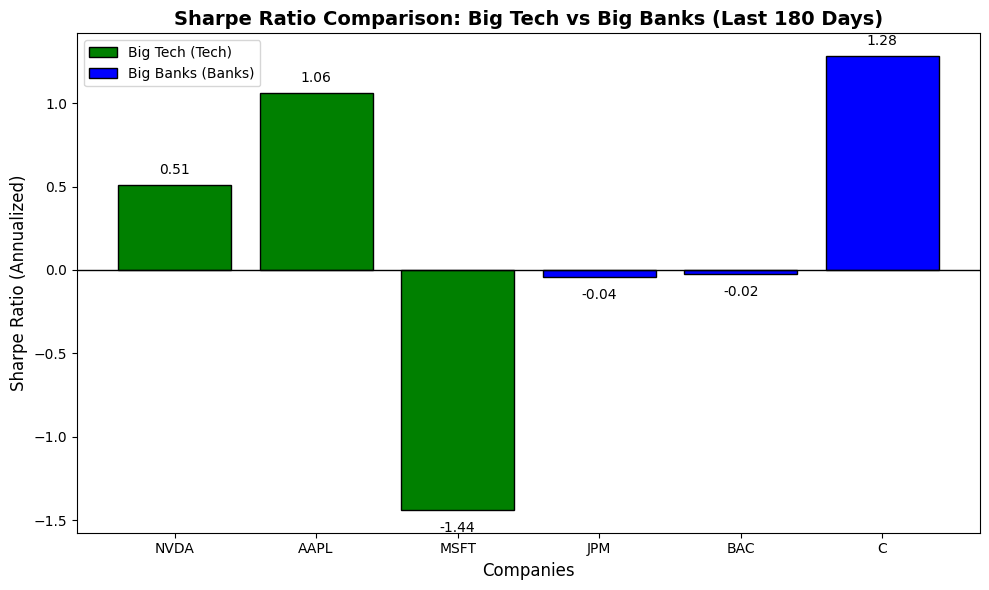

✅ Task Complete! The chart has been saved as 'sharpe_comparison.png'.


In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Data Ingestion
# ==========================================
print("Downloading stock data...")
tech_tickers = ['NVDA', 'AAPL', 'MSFT']
bank_tickers = ['JPM', 'BAC', 'C']
all_tickers = tech_tickers + bank_tickers

# Download daily closing prices for the last 180 days
data = yf.download(all_tickers, period="180d")['Close']

# ==========================================
# 2. Financial Math
# ==========================================
# Calculate Daily Returns (Percentage change)
daily_returns = data.pct_change().dropna()

# Calculate Sharpe Ratios: (Mean Return / Standard Deviation) * sqrt(252)
sharpe_ratios = {}
for ticker in all_tickers:
    mean_return = daily_returns[ticker].mean()
    std_return = daily_returns[ticker].std()
    sharpe_ratio = (mean_return / std_return) * np.sqrt(252)
    sharpe_ratios[ticker] = float(sharpe_ratio)

# ==========================================
# 3. Visualization
# ==========================================
print("Generating the chart...")
plt.figure(figsize=(10, 6))

# Prepare data and colors for the bar chart
tickers = list(sharpe_ratios.keys())
values = list(sharpe_ratios.values())

# Color coding: Green for Tech stocks, Blue for Bank stocks
colors = ['green' if t in tech_tickers else 'blue' for t in tickers]

# Draw the bar chart
bars = plt.bar(tickers, values, color=colors, edgecolor='black')

# Design details
plt.axhline(0, color='black', linewidth=1) # Zero line
plt.title('Sharpe Ratio Comparison: Big Tech vs Big Banks (Last 180 Days)', fontsize=14, fontweight='bold')
plt.ylabel('Sharpe Ratio (Annualized)', fontsize=12)
plt.xlabel('Companies', fontsize=12)

# Add a custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', edgecolor='black', label='Big Tech (Tech)'),
                   Patch(facecolor='blue', edgecolor='black', label='Big Banks (Banks)')]
plt.legend(handles=legend_elements, loc='upper left')

# Display values on top of the bars for better readability
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (0.05 if yval > 0 else -0.15),
             f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

# Save and show the plot
plt.tight_layout()
plt.savefig('sharpe_comparison.png')
plt.show()

print("✅ Task Complete! The chart has been saved as 'sharpe_comparison.png'.")